In [2]:
import sys
import os
from pathlib import Path
# Go up until you find the project root
while not (Path.cwd() / ".gitignore").exists() and Path.cwd() != Path("/"):
    os.chdir("..")


In [3]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import fiona
from shapely.geometry import Point
import matplotlib.pyplot as plt
import numpy as np
from src.utils import split_pa_train_test_spatially, split_pa_train_test_kmeans
from src.pa_split import partition_sweep

In [4]:
region = 'swi'  # example region code
group = ''
group_ = '_' if group != '' else ''
gdf_map = gpd.read_file(f'data/raw/NCEAS/Borders/{region}.gpkg')  # path for a .gpkg

# read data\raw\NCEAS\Records\train_po\AWTtrain_po.csv with region variable
df_po = gpd.read_file(f'data/processed/NCEAS/Records/train_po/{region.upper()}train_po{group_}{group}.csv')


# data\raw\NCEAS\Records\test_pa\AWTtest_pa_bird.csv
df_pa = gpd.read_file(f'data/raw/NCEAS/Records/test_pa/{region.upper()}test_pa{group_}{group}.csv')
df_env = pd.read_csv(f'data/raw/NCEAS/Records/test_env/{region.upper()}test_env{group_}{group}.csv')
df_pa[['x','y']] = df_pa[['x','y']].astype('float')
df_pa_tr, df_pa_te, foo1, foo2 = split_pa_train_test_spatially(df_pa, df_pa)

C:\Users\pablo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Divided the data into [0 1 2 3 4 5 6 7 8 9] clusters, [8 1 5] used for testing


In [4]:
df_env_covs = df_env.columns[4:]
df_env[df_env_covs] = (df_env[df_env_covs] - df_env[df_env_covs].mean())/df_env[df_env_covs].std()

# df_env_tr, df_env_te, foo1, foo2 = split_pa_train_test_kmeans(df_env, df_env, df_env_covs)


In [5]:
# from sklearn.metrics import pairwise_distances

# D_env = pairwise_distances(df_env[df_env_covs].values, metric='euclidean')   # pairwise distance for covariates
# partitions = partition_sweep(D_env)

In [6]:
from sklearn.metrics import pairwise_distances


df_xy = df_env[['x','y']].copy()
df_xy = (df_xy - df_xy.mean())/df_xy.std()
D_xy = pairwise_distances(df_xy.values, metric='euclidean')
partitions_xy = partition_sweep(D_xy, sample_every=100, max_iter = 1000)

Added after 100 iterations
Added after 200 iterations
Added after 300 iterations


In [7]:
gdf_points_po = gpd.GeoDataFrame(
    df_po,
    geometry=gpd.points_from_xy(df_po.x, df_po.y),
    crs=str(gdf_map.crs)  # Set CRS (important!)
    )

gdf_points_pa = gpd.GeoDataFrame(
    df_pa,
    geometry=gpd.points_from_xy(df_pa.x, df_pa.y),
    crs=str(gdf_map.crs)  # Set CRS (important!)
    )

gdf_points_pa_tr = gpd.GeoDataFrame(
    df_pa_tr,
    geometry=gpd.points_from_xy(df_pa_tr.x, df_pa_tr.y),
    crs=str(gdf_map.crs)  # Set CRS (important!)
    )

gdf_points_pa_te = gpd.GeoDataFrame(
    df_pa_te,
    geometry=gpd.points_from_xy(df_pa_te.x, df_pa_te.y),
    crs=str(gdf_map.crs)  # Set CRS (important!)
    )

# gdf_points_env_tr = gpd.GeoDataFrame(
#     df_env_tr,
#     geometry=gpd.points_from_xy(df_env_tr.x, df_env_tr.y),
#     crs=str(gdf_map.crs)  # Set CRS (important!)
#     )

# gdf_points_env_te = gpd.GeoDataFrame(
#     df_env_te,
#     geometry=gpd.points_from_xy(df_env_te.x, df_env_te.y),
#     crs=str(gdf_map.crs)  # Set CRS (important!)
#     )



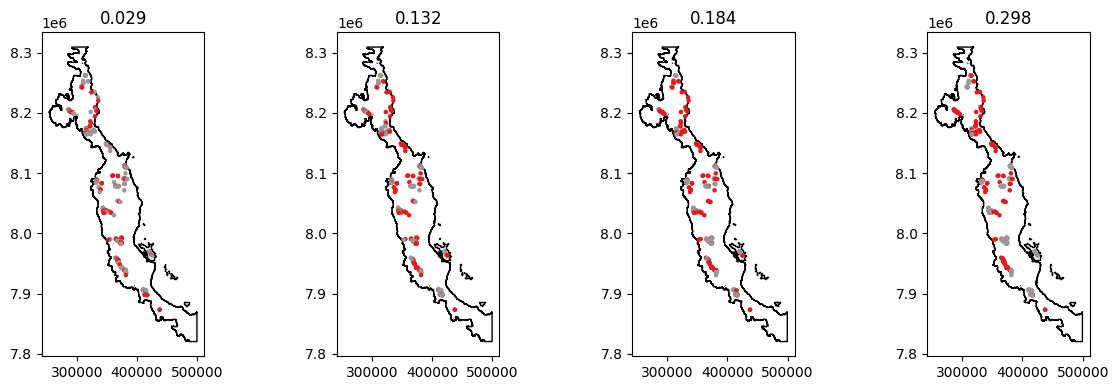

In [8]:
n = len(partitions_xy)
cols = 4
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(12, 4*rows))

axes = axes.flatten()

for ax, p in zip(axes, partitions_xy):
    A, B = p["A"], p["B"]

    gdf_points_pa["set"] = "A"
    gdf_points_pa.loc[B, "set"] = "B"

    gdf_map.plot(ax=ax, color="white", edgecolor="black")
    gdf_points_pa.plot(ax=ax, column="set", cmap="Set1", markersize=5)

    ax.set_title(f"{p['dist_metric']:.3f}")

# hide unused axes
for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

<Axes: >

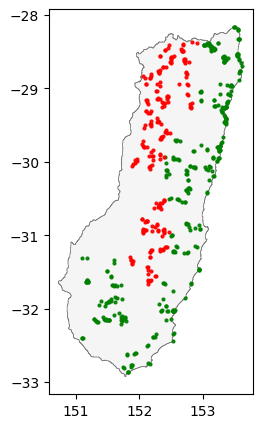

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
gdf_map.plot(ax=ax, color="whitesmoke", edgecolor="gray", linewidth=0.5)
gdf_points_pa_tr.plot(ax=ax, color="green", markersize=4, label="Train", alpha=0.9)
gdf_points_pa_te.plot(ax=ax, color="red", markersize=4, label="Test", alpha=0.9)

<Axes: >

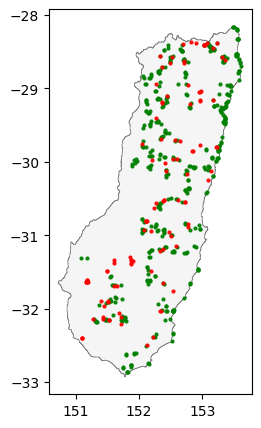

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
gdf_map.plot(ax=ax, color="whitesmoke", edgecolor="gray", linewidth=0.5)
gdf_points_env_tr.plot(ax=ax, color="green", markersize=4, label="Train", alpha=0.9)
gdf_points_env_te.plot(ax=ax, color="red", markersize=4, label="Test", alpha=0.9)

In [ ]:
def plot_sd(gdf_points_po, gdf_points_pa, gdf_map, title, plot_pa_separately=False):
# Make the figure larger
    fig, ax = plt.subplots(figsize=(10, 10))

    # Base map (GeoPackage layer)
    gdf_map.plot(ax=ax, color="whitesmoke", edgecolor="gray", linewidth=0.5)

    if plot_pa_separately:
        # separate column PA in 0 and 1
        gdf_points_pa_1 = gdf_points_pa[gdf_points_pa['PA'] == 1]
        gdf_points_pa_0 = gdf_points_pa[gdf_points_pa['PA'] == 0]
        # Points layers PA=1
        gdf_points_pa_1.plot(
            ax=ax,
            color="green",
            markersize=4,
            label="PA=1",
            alpha=0.9
        )
        # Points layers PA=0
        gdf_points_pa_0.plot(
            ax=ax,
            color="blue",
            markersize=1,
            label="PA=0",
            alpha=0.3
        )
    else:
            # Points layers PA
        gdf_points_pa.plot(
            ax=ax,
            color="blue",
            markersize=4,
            label="PA",
            alpha=0.6
        )
    # Points layers
    gdf_points_po.plot(
        ax=ax,
        color="red",
        markersize=4,
        label="PO",
        alpha=0.7
    )

    # Add title, labels, legend
    # ax.set_title("PO & PA Points over Base Map", fontsize=16, fontweight="bold")
    ax.set_title(title, fontsize=14)
    # ax.set_xlabel("Longitude", fontsize=12)
    # ax.set_ylabel("Latitude", fontsize=12)
    ax.legend(title="Data Source", loc="upper right")

    # Add grid and frame
    ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.7)
    ax.set_facecolor("aliceblue")

    # Remove axis spines for a clean look
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Show plot
    plt.tight_layout()
    plt.show()


Species ID: nsw01 - PA=1 ratio: 0.21, Total PA points: 570


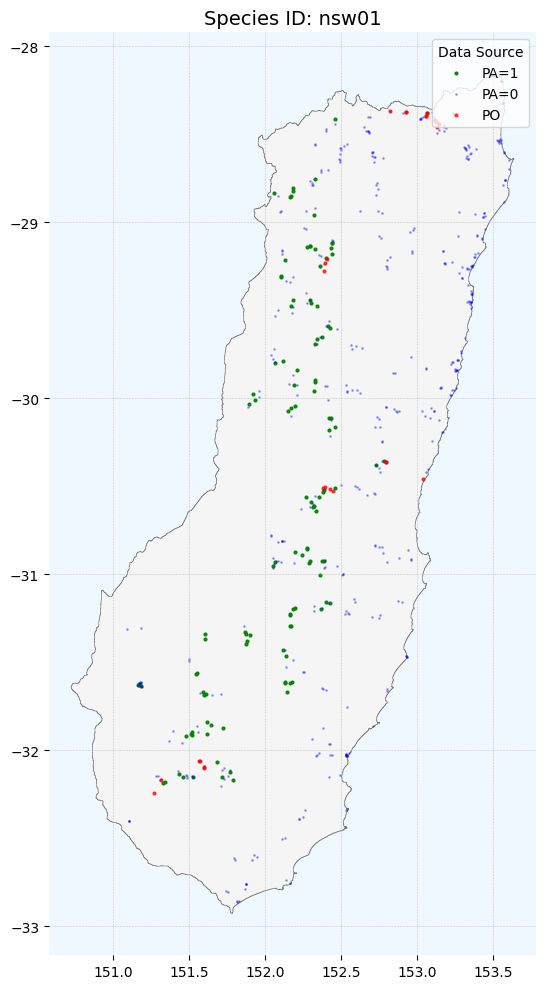

Species ID: nsw02 - PA=1 ratio: 0.18, Total PA points: 570


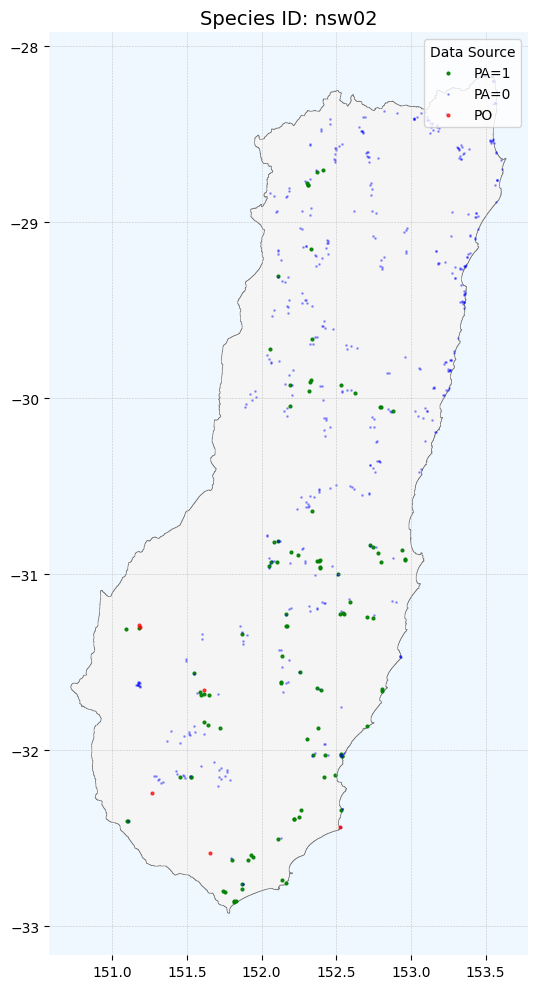

Species ID: nsw03 - PA=1 ratio: 0.04, Total PA points: 570


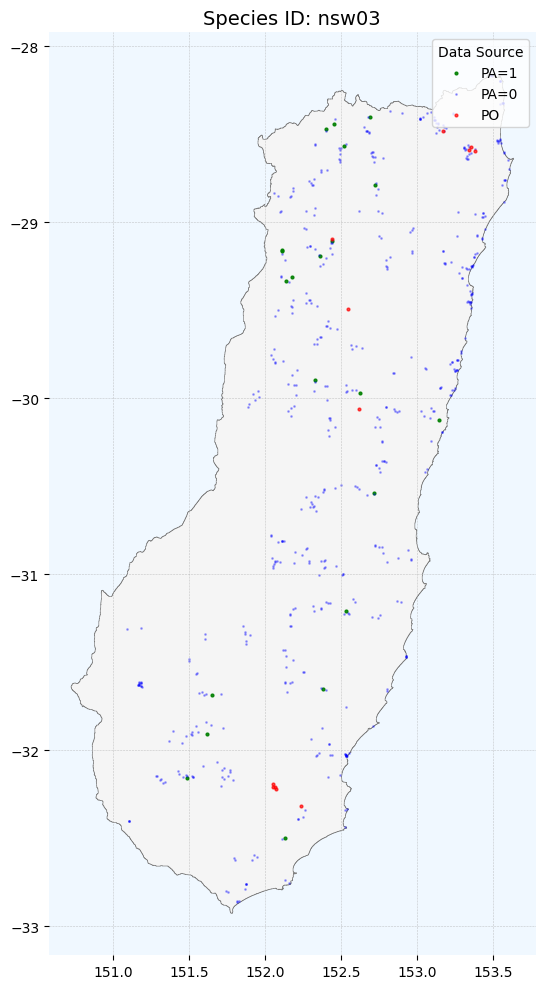

Species ID: nsw04 - PA=1 ratio: 0.02, Total PA points: 570


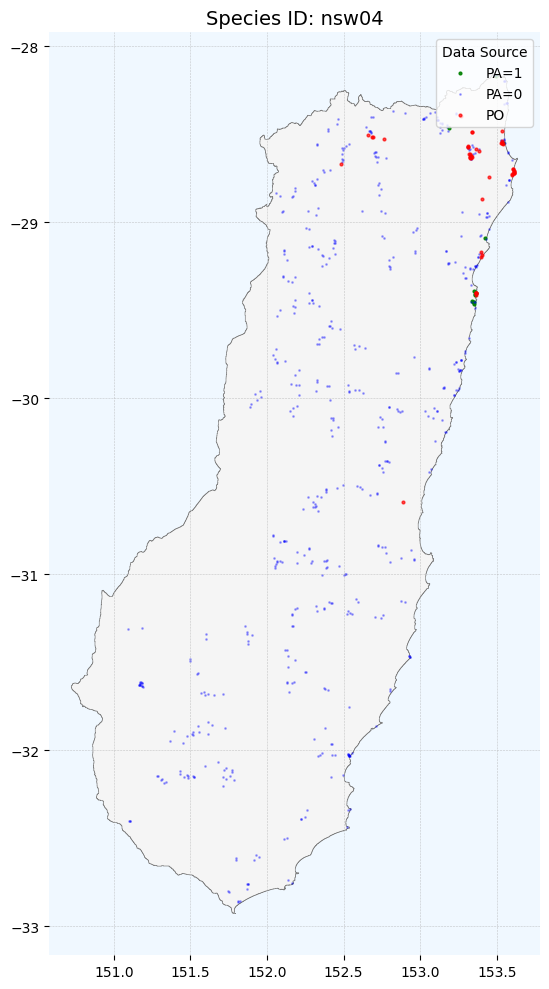

Species ID: nsw05 - PA=1 ratio: 0.07, Total PA points: 570


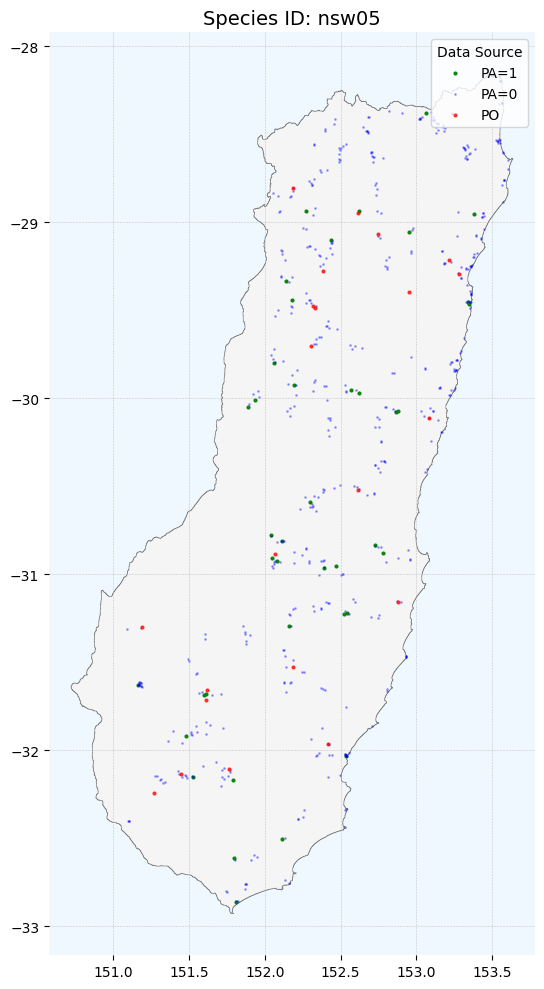

Species ID: nsw06 - PA=1 ratio: 0.33, Total PA points: 570


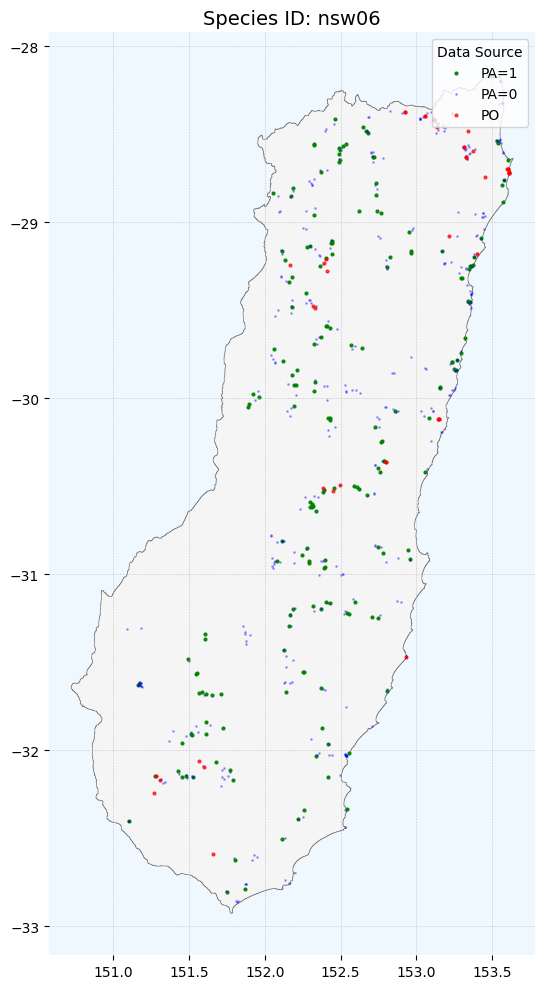

Species ID: nsw07 - PA=1 ratio: 0.08, Total PA points: 570


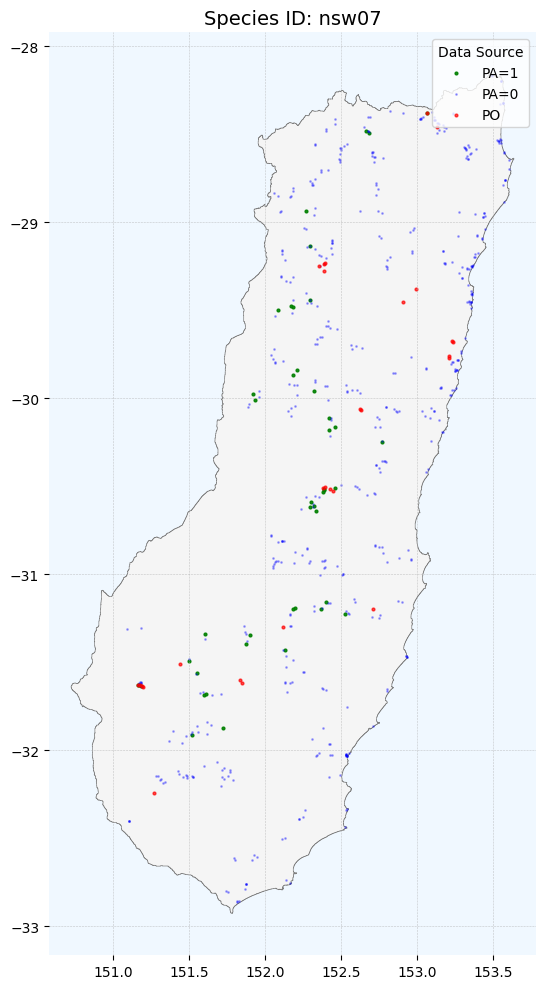

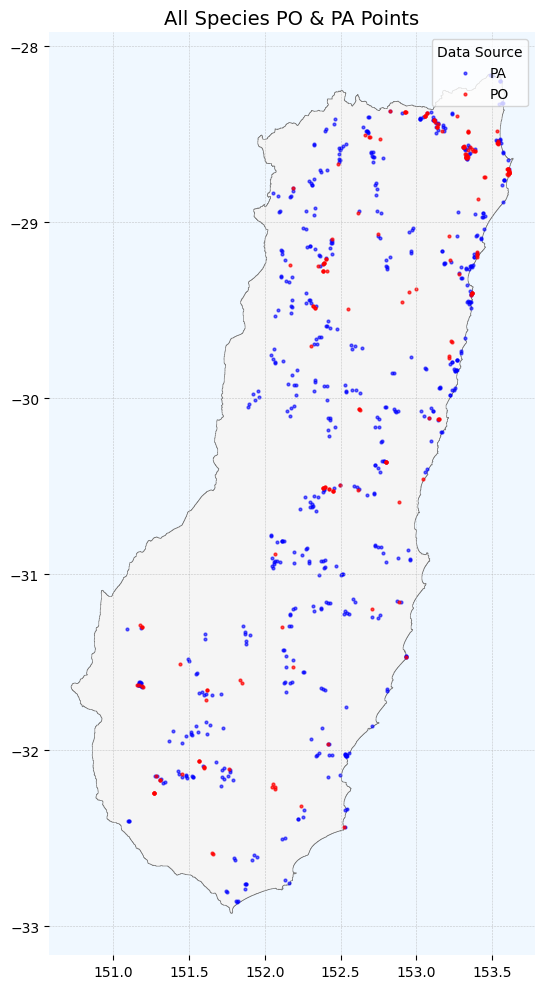

In [ ]:
unique_species = gdf_points_po['spid'].unique()
plot_pa_separately = True  # Set to True to plot PA=1 and PA=0 separately

for sp in unique_species:

    gdf_points_po_sp = gdf_points_po[gdf_points_po['spid'] == sp]
    gdf_points_pa_sp = gdf_points_pa.copy()#[gdf_points_pa['spid'] == sp]
    if plot_pa_separately:
        gdf_points_pa_sp['PA'] = gdf_points_pa_sp[sp].astype(int)

    # count how many of the total are PA=1
    ratio = gdf_points_pa_sp['PA'].sum() / len(gdf_points_pa_sp)
    print(f"Species ID: {sp} - PA=1 ratio: {ratio:.2f}, Total PA points: {len(gdf_points_pa_sp)}")

    plot_sd(gdf_points_po_sp, gdf_points_pa_sp, gdf_map, title=f"Species ID: {sp}", plot_pa_separately=plot_pa_separately)

# plot the spatial distribution for all species together
plot_sd(gdf_points_po, gdf_points_pa, gdf_map, title="All Species PO & PA Points")



